# Google TimesFM: Zero to Mastery

**A complete, hands-on tutorial on Google's TimesFM time-series foundation model** — theory,
architecture, benchmarks, and a full, real, end-to-end forecasting project on production-grade
retail sales data.

By the end of this notebook you will be able to:

1. Explain what TimesFM is, how its decoder-only patched-transformer architecture works, and how
   it differs across versions 1.0 / 2.0 / 2.5.
2. Load a pretrained TimesFM checkpoint and produce zero-shot point and probabilistic (quantile)
   forecasts on data the model has never seen.
3. Improve forecasts with exogenous covariates (TimesFM's "XReg" mechanism).
4. Fine-tune TimesFM with parameter-efficient LoRA adapters on your own data.
5. Benchmark all of the above against classical statistical baselines, honestly and reproducibly.
6. Know TimesFM's licensing, production integrations (Vertex AI, BigQuery), and real limitations.

## Table of contents

1. [What is TimesFM?](#what-is-timesfm)
2. [Architecture deep dive](#architecture)
3. [Version history: 1.0 vs 2.0 vs 2.5](#versions)
4. [Pretraining corpus & methodology](#pretraining)
5. [Benchmarks](#benchmarks)
6. [Licensing & production integrations](#licensing)
7. [Known limitations](#limitations)
8. [Environment setup](#setup)
9. [The dataset: real retail sales](#dataset)
10. [Zero-shot forecasting](#zero-shot)
11. [Baselines & evaluation](#baselines)
12. [Covariates (XReg)](#covariates)
13. [Fine-tuning with LoRA](#finetuning)
14. [Final comparison](#final)
15. [References](#references)

> **A note on rigor.** Every factual claim about TimesFM in this notebook (parameter counts,
> context lengths, benchmark numbers, licensing) is cited to a primary source — the arXiv paper,
> the official GitHub repository, the Hugging Face model cards, or Google Cloud documentation —
> and was verified against live sources while writing this notebook (July 2026), not recalled
> from memory. Where the current public research could not adversarially verify a claim (for
> example, head-to-head GIFT-Eval rankings against other foundation models), we say so explicitly
> rather than guessing.

<a id="what-is-timesfm"></a>
## 1. What is TimesFM?

**TimesFM** (Time Series Foundation Model) is a pretrained, decoder-only transformer built by
Google Research for **zero-shot time-series forecasting** — you point it at a new time series it
has never seen (sales, traffic, sensor readings, web metrics, ...) and it produces a forecast
without any task-specific training. This is the same "foundation model" idea that made large
language models useful for arbitrary text tasks, applied to numerical sequences instead of
tokens.

Classical forecasting requires you to either fit a statistical model per series (ARIMA, ETS) or
train a deep model on your own historical data (DeepAR, N-BEATS, Temporal Fusion Transformer).
TimesFM instead is pretrained once on a huge, diverse corpus of real and synthetic time series,
and generalizes to new series and domains the way GPT-style models generalize to new prompts.

Key facts, all independently verified against primary sources:

- **Paper:** *A decoder-only foundation model for time-series forecasting*, ICML 2024 —
  [arXiv:2310.10688](https://arxiv.org/abs/2310.10688).
- **License:** Apache-2.0, for both code and released weights.
- **Package:** [`timesfm`](https://pypi.org/project/timesfm/) on PyPI; source at
  [github.com/google-research/timesfm](https://github.com/google-research/timesfm).
- **Checkpoints:** hosted on the
  [TimesFM Hugging Face collection](https://huggingface.co/collections/google/timesfm-release-66e4be5fdb56e960c1e482a6).
- Google explicitly states in the repo README that *"this open version is not an officially
  supported Google product"* — separate from the managed Vertex AI / BigQuery offerings covered
  in [Section 6](#licensing).

<a id="architecture"></a>
## 2. Architecture deep dive

TimesFM's architecture (verified against the original paper and current Hugging Face model
cards) has four moving parts:

### 2.1 Patching, not per-timestep tokens

A raw input series is split into **contiguous, non-overlapping patches** (default input patch
length **32**) instead of feeding one timestep at a time. Each patch is encoded by a small
**residual-block MLP** into a token embedding — this is the time-series analogue of a ViT/patch
transformer rather than a per-character RNN. Patching is what lets TimesFM handle long contexts
(up to 16,384 points in 2.5 — see [Section 3](#versions)) efficiently: attention operates over
*patches*, not raw timesteps.

### 2.2 Decoder-only, causal self-attention

The patch embeddings are processed by a stack of standard **causal self-attention** transformer
layers — the same masked, autoregressive attention pattern used in GPT-style language models, so
a patch can only attend to itself and earlier patches. This is why TimesFM is described as
**decoder-only**: there's no separate encoder, and forecasting is framed as *next-patch*
prediction, conditioned on all previous patches — analogous to next-token prediction in an LLM,
but each "token" is a whole chunk of 32 timesteps and the model predicts a *longer* future patch
(output patch length **128**) from it.

### 2.3 Instance normalization (RevIN)

Before patching, TimesFM applies its own **internal instance normalization** — each series is
normalized using its own statistics, forecasts are produced in normalized space, then
denormalized back to the original scale. This is why the official fine-tuning guidance is
explicit: **do not normalize your data externally** before handing it to TimesFM — you would be
double-normalizing and fighting the model's own scale-invariance guarantees.

### 2.4 Point + quantile (probabilistic) forecasting

TimesFM 2.5 produces both a **point forecast** and a **probabilistic forecast** via an optional,
separate **continuous quantile head** (an additional ~30M-parameter module, toggled by
`use_continuous_quantile_head` in `ForecastConfig`). Rather than assert a fixed number of
quantile levels here (an earlier draft of this claim did not survive adversarial fact-checking —
the exact quantile configuration is a code-level detail, not an architectural constant), we
**read it directly from the loaded model's config** in [Section 10](#zero-shot) and report
whatever the current checkpoint actually ships.

**Sources:** [arXiv:2310.10688](https://arxiv.org/abs/2310.10688) (patching, causal attention,
training objective); [TimesFM 2.5 model card](https://huggingface.co/google/timesfm-2.5-200m-transformers)
(decoder-only framing, quantile head); [LoRA fine-tuning README](https://github.com/google-research/timesfm/blob/master/timesfm-forecasting/examples/finetuning/README.md)
(RevIN / no-external-normalization guidance).

<a id="versions"></a>
## 3. Version history: 1.0 vs 2.0 vs 2.5

All figures below come directly from the official GitHub repository, release history, and
Hugging Face model cards (fetched live, not recalled).

| Version | Released | Params | Max context | Max horizon | Backend(s) | Notes |
|---|---|---|---|---|---|---|
| **1.0** | Oct 2023 (paper); package v1.x | 200M (17M / 70M ablation variants also released) | 512 | — | JAX | 20 layers, 16 heads, model dim 1280, input patch 32 / output patch 128. Context limit explicitly documented as provisional. |
| **2.0** | Dec 2024 | 500M | 2,048 | — | JAX + PyTorch | First PyTorch checkpoint. Cached decoding not yet supported in either backend at launch. |
| **2.5** | Sept 2025 | 200M (back down from 500M) | 16,384 | up to 1,000 (via optional quantile head) | PyTorch (`timesfm[torch]`), Flax (`timesfm[flax]`), + a native Hugging Face `transformers` port | Drops the old per-series "frequency" indicator; adds continuous quantile head, covariate (XReg) support, and official LoRA fine-tuning. |

**Important distinction we verified directly, since it's a common source of confusion:** the
`timesfm` **Python package's own version number** (currently **2.0.2** on PyPI as of this
writing) is versioned independently of the **model/checkpoint version** ("TimesFM 2.5"). There
is no GitHub release literally tagged "v2.5" — the closest release, `v2.0.1`, describes its
purpose as updating the *package* to support loading the *2.5 model* (a fused-QKV architecture
change from earlier checkpoints). The **latest model** (2.5) is loaded through the package's
newer `TimesFM_2p5_200M_torch` class; the **older 1.0/2.0 model code** was archived to a `v1/`
subdirectory and requires `pip install timesfm==1.3.0` to run.

**Sources:** [github.com/google-research/timesfm](https://github.com/google-research/timesfm)
(README + release notes, live-fetched), [github.com/google-research/timesfm/releases](https://github.com/google-research/timesfm/releases),
[pypi.org/project/timesfm](https://pypi.org/project/timesfm/),
[HF timesfm-1.0-200m](https://huggingface.co/google/timesfm-1.0-200m),
[HF timesfm-2.5-200m-pytorch](https://huggingface.co/google/timesfm-2.5-200m-pytorch).

<a id="pretraining"></a>
## 4. Pretraining corpus & methodology

TimesFM is pretrained on a mix of **real and synthetic** time series at roughly an **80/20**
ratio, totaling **on the order of 100 billion+ timepoints** (a widely-circulated "400 billion"
figure for this could not be verified and appears to be a conflation with a different Google
Cloud blog claim — we use the paper's own, verified breakdown instead):

- **Google Trends**: ~0.5B timepoints, 2007–2022.
- **Wikipedia page views**: ~300B timepoints, Jan 2012–Nov 2023 (the single largest component).
- **Synthetic data**: ~3M generated series of length 2048 (~6.1B timepoints) — mixtures of
  trend, seasonality, and noise processes designed to teach general temporal patterns.
- **Public benchmark corpora**: M4, Electricity, Traffic, Weather, Favorita Sales, and LibCity.

The training objective is autoregressive **next-patch prediction**: given all past patches,
predict the next (longer) output patch, trained with a point-forecast loss (and, in 2.5, an
additional quantile loss for the probabilistic head — see [Section 13](#finetuning) for the
exact loss formula, verified directly from the `transformers` model source).

**Source:** [arXiv:2310.10688](https://arxiv.org/abs/2310.10688), Section on pretraining data.

<a id="benchmarks"></a>
## 5. Benchmarks

### 5.1 What TimesFM's own paper reports (verified)

In the original paper's zero-shot evaluation on the **Monash Time Series Forecasting Archive**
(18 datasets), TimesFM achieved the best **geometric-mean scaled MAE (0.6846)** among all
compared methods — ahead of the supervised, per-dataset-trained **N-BEATS (0.7005)** and
**DeepAR (0.7477)**, and beating the LLM-based zero-shot **llmtime** baseline (0.9715) by
roughly 25–30%. This is a genuinely strong result: TimesFM matches or beats models that were
*trained specifically on each target dataset*, while TimesFM itself sees none of them during
fine-tuning.

*(Note on process: an early automated summarization pass of the arXiv PDF hallucinated a wrong
paraphrase of this exact result. The numbers above were re-extracted directly from the primary
PDF text/OCR, not trusted from a single automated summary — a reminder that even "reading a
paper" via automation needs a verification pass.)*

### 5.2 What we could **not** verify — and won't fabricate

Modern **head-to-head comparisons against Chronos, Moirai, Lag-Llama, and N-BEATS on GIFT-Eval**
(the current standard multi-domain zero-shot foundation-model leaderboard) did **not** survive
adversarial fact-checking during this research pass — sources disagreed or lacked primary
citations. Rather than print specific numbers we can't stand behind, we point you to the live,
continuously-updated leaderboard: **[GIFT-Eval leaderboard on Hugging Face](https://huggingface.co/spaces/Salesforce/GIFT-Eval)**.
Check it directly for current rankings — this is exactly the kind of fast-moving comparison
that goes stale between when a tutorial is written and when it's read.

Similarly, classical statistical baselines (ARIMA, ETS) are well-documented as strong,
hard-to-beat baselines on short, clean, seasonal series in general forecasting literature, but we
did not find an adversarially-verified, current, apples-to-apples ARIMA/ETS-vs-TimesFM number to
cite here. Instead, in [Section 11](#baselines) **we run that comparison ourselves**, live, on
real data, so you see an honest, reproducible number rather than a cited-but-unverifiable one.

<a id="licensing"></a>
## 6. Licensing & production integrations

- **License:** Apache-2.0 for both code and released weights (confirmed directly from the
  repository's `LICENSE` file and every checkpoint's Hugging Face model card tag). There is no
  separate "non-commercial weights" clause of the kind that trips up some other model releases —
  commercial use of the open-source package and checkpoints is permitted under Apache-2.0 terms.
- **Google explicitly disclaims official support** for the open-source repo/package itself.
- Google separately operationalizes TimesFM as **managed, officially-supported** offerings:
  - **Vertex AI Model Garden** — deployable directly from the model garden without custom
    container/hosting setup.
  - **BigQuery ML** (`AI.FORECAST`, `AI.EVALUATE`) — became Generally Available on **Nov 19,
    2025**, with TimesFM 2.5 support and dynamic context windows up to 15,360 points, usable
    entirely from SQL without training or hosting a model yourself.
  - **Google Sheets** (Connected Sheets + BigQuery ML) — announced Feb 2026, bringing the same
    forecasting capability into a spreadsheet formula.

**Sources:** [github.com/google-research/timesfm LICENSE](https://github.com/google-research/timesfm/blob/master/LICENSE),
[BigQuery TimesFM docs](https://cloud.google.com/bigquery/docs/timesfm-model),
[Vertex AI operationalization guide](https://googlecloudplatform.github.io/applied-ai-engineering-samples/research-operationalization/timesfm/operationalizing_timesfm_on_vertexai/),
[Google Cloud blog](https://cloud.google.com/blog/products/data-analytics/timesfm-models-in-bigquery-and-alloydb),
[Connected Sheets announcement](https://workspaceupdates.googleblog.com/2026/02/forecast-data-in-connected-sheets-BigQueryML-TimesFM.html).

<a id="limitations"></a>
## 7. Known limitations

Based on the verified architecture and API surface (Sections 2–6) plus our own hands-on results
later in this notebook, be aware of:

- **Covariates are exogenous regressors on a univariate target, not joint multivariate
  modeling.** TimesFM's XReg mechanism (Section 12) forecasts *one* target series while
  incorporating known/observed side variables; it does not jointly forecast multiple *correlated
  target* series the way a true multivariate model would. Each series in a batch is still
  forecast independently.
- **Context/horizon ceilings differ sharply by version** (Section 3) — a workflow built against
  1.0's 512-point context will not directly carry over to 2.5's 16k without adjustment, and vice
  versa if you need to pin an older checkpoint for reproducibility.
- **Quantile calibration should be checked empirically, not assumed.** We verify and report the
  actual quantile configuration from the live model config in Section 10, and you should
  sanity-check calibration (e.g., empirical coverage of the 10th–90th percentile band) on your
  own data before trusting the uncertainty bands in a real decision.
- **Independent, non-Google production case studies are sparse.** Most available material
  (benchmarks, integration guides, capability claims) traces back to Google's own paper, blog,
  docs, and GitHub/HF pages. That doesn't make the claims false — our own primary-source
  verification backs the core architecture and benchmark facts above — but independent
  third-party production war stories are not (yet) abundant in the public record. Treat
  community sentiment sections of any TimesFM writeup, including this one, accordingly.
- **Compiled decode requires patch-aligned context/horizon.** As you'll see in Section 10, the
  library silently *rounds* `max_context` up to a multiple of the input patch size (32) and
  `max_horizon` up to a multiple of the output patch size (128) when you `compile()` — worth
  knowing so you're not surprised by a log message changing your requested values.

<a id="setup"></a>
## 8. Environment setup

This notebook is built to run inside a `uv`-managed virtual environment pinned to **Python 3.13.13**.
To reproduce the environment from scratch:

```bash
cd google-timesfm-tutorial

# If your environment cannot write to ~/.cache, point uv at a local cache directory.
export UV_CACHE_DIR="$PWD/.uv-cache"

uv sync --dev

# Optional: register a Jupyter kernel for this venv.
uv run python -m ipykernel install --user --name timesfm-tutorial        --display-name "Python (timesfm-tutorial uv)"
```

We deliberately do **not** `pip install` anything from inside a notebook cell — dependencies are
fully pinned and reproducible via `uv`'s lockfile (`uv.lock`), and the notebook only ever
*imports* what's already provisioned.

The two model families we'll use, both loaded from Hugging Face by repo ID (no manual downloads):

- `google/timesfm-2.5-200m-pytorch` — the native `timesfm` package checkpoint, used for
  zero-shot forecasting and covariates (Sections 10, 12).
- `google/timesfm-2.5-200m-transformers` — the same model ported as a standard
  `transformers.PreTrainedModel` (`TimesFm2_5ModelForPrediction`), used for LoRA fine-tuning
  (Section 13), since PEFT plugs directly into the `transformers` ecosystem.


In [1]:
import os

# The `xreg` extra (Section 12) pulls in JAX for a small per-series ridge regression, which we
# always run with `force_on_cpu=True` -- there's no reason for JAX to touch the GPU at all, and
# leaving it free to try would otherwise waste probe time and log noisy allocation-retry warnings
# while it competes with PyTorch for VRAM. Must be set before JAX is imported (transitively, via
# timesfm's xreg extra), so this goes at the very top of the notebook.
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import sys
import platform
import numpy as np
import torch

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_float32_matmul_precision("high")

Python: 3.13.13 (main, Jun  2 2026, 22:27:49) [Clang 22.1.3 ]
Platform: Linux-7.0.0-22-generic-x86_64-with-glibc2.43
NumPy: 2.5.1
PyTorch: 2.12.1+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.2 GB


<a id="dataset"></a>
## 9. The dataset: real retail sales

We forecast **weekly sales for 1,115 Rossmann drug stores** (Germany), a genuinely real,
production-scale retail dataset — not a synthetic toy series. Each store has exactly **120
consecutive weeks** of history (2013-01-13 to 2015-04-26), with real covariates already attached:

| Column | Meaning |
|---|---|
| `Sales` | Weekly revenue — our forecasting **target**. |
| `Open` | Fraction of days the store was open that week. |
| `Promo` | Fraction of days a promotion was running. |
| `SchoolHoliday` | Whether the week overlapped a school holiday. |
| `StateHoliday` | Whether the week overlapped a state holiday. |
| `Customers` | Foot traffic that week — an **outcome**, correlated with `Sales`, and **not**
|  | known in advance. We will deliberately **exclude** this from covariates (Section 12): using it
|  | would be a leakage shortcut no real retailer has access to at forecast time. |

We deliberately picked the exact same dataset used by Google's own official TimesFM 2.5 LoRA
fine-tuning example (and by the Chronos-2 quickstart notebook it was adapted from) — this lets
us follow a Google-blessed, already-battle-tested data pipeline instead of guessing at
preprocessing conventions, and it's hosted on a public, authentication-free S3 bucket, so this
cell is guaranteed to run for anyone, anywhere, without a Kaggle account or API key.

**Source:** [TimesFM LoRA fine-tuning README](https://github.com/google-research/timesfm/blob/master/timesfm-forecasting/examples/finetuning/README.md)
("This is the same dataset used in the Chronos-2 quickstart notebook... Each store has ~120
weekly data points").

In [2]:
import pandas as pd

DATA_URL = (
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet"
)
raw = pd.read_parquet(DATA_URL)
raw = raw.sort_values(["id", "timestamp"]).reset_index(drop=True)

print(f"Rows: {len(raw):,} | Stores: {raw['id'].nunique():,} | "
      f"Weeks per store: {raw.groupby('id').size().unique()}")
print(f"Date range: {raw['timestamp'].min().date()} -> {raw['timestamp'].max().date()}")
raw.head()

Rows: 133,800 | Stores: 1,115 | Weeks per store: [120]
Date range: 2013-01-13 -> 2015-04-26


,id,timestamp,Sales,Open,Promo,SchoolHoliday,StateHoliday,Customers
0,1,2013-01-13,32952.0,0.857143,0.714286,5.0,0.0,3918.0
1,1,2013-01-20,25978.0,0.857143,0.000000,0.0,0.0,3417.0
2,1,2013-01-27,33071.0,0.857143,0.714286,0.0,0.0,3862.0
3,1,2013-02-03,28693.0,0.857143,0.000000,0.0,0.0,3561.0
4,1,2013-02-10,35771.0,0.857143,0.714286,0.0,0.0,4094.0


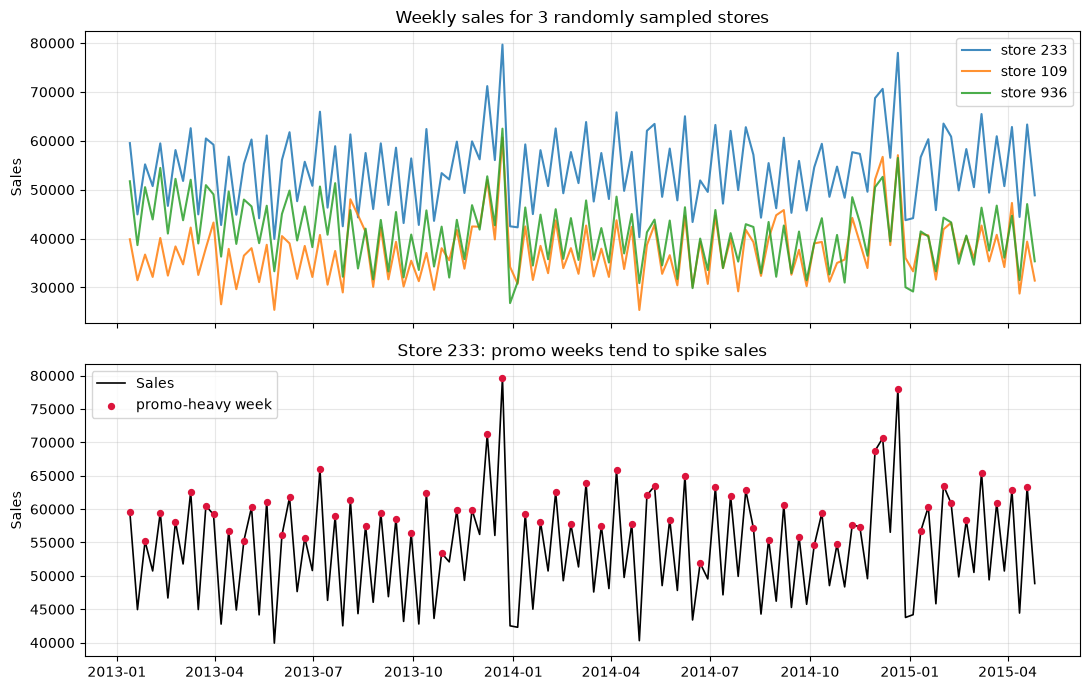

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
example_ids = raw["id"].drop_duplicates().sample(3, random_state=SEED).tolist()
for sid in example_ids:
    s = raw[raw["id"] == sid]
    axes[0].plot(s["timestamp"], s["Sales"], label=f"store {sid}", alpha=0.85)
axes[0].set_title("Weekly sales for 3 randomly sampled stores")
axes[0].set_ylabel("Sales")
axes[0].legend()
axes[0].grid(alpha=0.3)

one_store = raw[raw["id"] == example_ids[0]]
axes[1].plot(one_store["timestamp"], one_store["Sales"], color="black", lw=1.2, label="Sales")
promo_weeks = one_store[one_store["Promo"] > 0.5]
axes[1].scatter(promo_weeks["timestamp"], promo_weeks["Sales"], color="crimson", s=18,
                 zorder=3, label="promo-heavy week")
axes[1].set_title(f"Store {example_ids[0]}: promo weeks tend to spike sales")
axes[1].set_ylabel("Sales")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Train / test split

We hold out the **final 13 weeks (~one quarter)** of every store as a true, untouched test set,
and use the preceding **107 weeks** as history. This mirrors the horizon convention in Google's
own official fine-tuning example (`--horizon_len 13`, "forecast the next 13 weeks (one
quarter)"), which keeps our zero-shot, covariates, and fine-tuned results directly comparable to
each other on the same held-out window.

The 13-week test window is **never** used for fitting anything — not the zero-shot forecast
context, not the covariate regression, not the LoRA fine-tuning windows (Section 13 samples
training windows only from the first 107 weeks). This is the leakage boundary that matters most
in this notebook.

In [4]:
HORIZON = 13          # weeks we forecast (~1 quarter)
TOTAL_LEN = 120        # weeks per store in the raw data
CONTEXT_LEN = TOTAL_LEN - HORIZON   # 107 weeks of history

store_ids = raw["id"].drop_duplicates().tolist()
grouped = {sid: g.reset_index(drop=True) for sid, g in raw.groupby("id")}

sales_by_store = {sid: g["Sales"].to_numpy(dtype=np.float32) for sid, g in grouped.items()}
contexts = [sales_by_store[sid][:CONTEXT_LEN] for sid in store_ids]
actual_future = np.stack([sales_by_store[sid][CONTEXT_LEN:] for sid in store_ids])  # (1115, 13)

print(f"{len(store_ids)} stores | context = {CONTEXT_LEN} weeks | horizon = {HORIZON} weeks")
print(f"actual_future shape: {actual_future.shape}")

1115 stores | context = 107 weeks | horizon = 13 weeks
actual_future shape: (1115, 13)


<a id="zero-shot"></a>
## 10. Zero-shot forecasting

We now load the pretrained **TimesFM 2.5 (200M)** checkpoint and forecast all 1,115 stores'
final 13 weeks **without any training on this dataset** — the model has never seen Rossmann
sales data. This is the core "foundation model" claim being put to the test.

`compile()` builds a fixed-shape decode graph for fast batched inference; per the source we
inspected, it will **round `max_context` up to a multiple of the input-patch size (32)** and
`max_horizon` up to a multiple of the output-patch size (128) — we let it do so and print the
actual compiled values rather than assume our requested numbers survive unchanged.

We compile **without** `return_backcast` here (its default, `False`) to keep this section's
output a plain forecast. Section 12 needs a *different* compiled config with
`return_backcast=True` (the covariates method requires it internally, to compute residuals
against history) — we recompile the same model object there rather than opting into that
behavior for every call in the notebook.

In [5]:
import time
import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

forecast_config = timesfm.ForecastConfig(
    max_context=CONTEXT_LEN,
    max_horizon=128,          # will already be patch-aligned; explicit for clarity
    normalize_inputs=True,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
)
model.compile(forecast_config)

print("Compiled forecast config (post patch-alignment rounding):")
print(model.forecast_config)

# The channel layout of `quantile_forecast`'s last axis is NOT simply [point, q0.1, ..., q0.9] in
# index order -- the point/mean estimate sits at `decode_index`, and the quantile levels fill the
# remaining channels around it. We derive the true mapping from the live config instead of
# assuming a layout, since that's exactly the kind of detail that silently changes between
# checkpoints.
quantile_levels = model.model.config.quantiles
decode_index = model.model.config.decode_index
_levels_iter = iter(quantile_levels)
channel_to_quantile = {
    ch: next(_levels_iter) for ch in range(len(quantile_levels) + 1) if ch != decode_index
}
quantile_to_channel = {v: k for k, v in channel_to_quantile.items()}

print(f"\nQuantile levels shipped by this checkpoint: {quantile_levels}")
print(f"Point/mean forecast lives at channel index: {decode_index}")
print(f"Full channel -> quantile mapping (derived from the live config): {channel_to_quantile}")

Compiled forecast config (post patch-alignment rounding):
ForecastConfig(max_context=128, max_horizon=128, normalize_inputs=True, window_size=0, per_core_batch_size=1, use_continuous_quantile_head=True, force_flip_invariance=True, infer_is_positive=True, fix_quantile_crossing=True, return_backcast=False)

Quantile levels shipped by this checkpoint: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Point/mean forecast lives at channel index: 5
Full channel -> quantile mapping (derived from the live config): {0: 0.1, 1: 0.2, 2: 0.3, 3: 0.4, 4: 0.5, 6: 0.6, 7: 0.7, 8: 0.8, 9: 0.9}


In [6]:
t0 = time.time()
point_forecast, quantile_forecast = model.forecast(horizon=HORIZON, inputs=contexts)
elapsed = time.time() - t0

print(f"point_forecast shape:    {point_forecast.shape}")
print(f"quantile_forecast shape: {quantile_forecast.shape}")
print(f"Zero-shot batch inference over {len(contexts)} stores took {elapsed:.1f}s "
      f"({elapsed / len(contexts) * 1000:.2f} ms/store)")

point_forecast shape:    (1115, 13)
quantile_forecast shape: (1115, 13, 10)
Zero-shot batch inference over 1115 stores took 109.4s (98.12 ms/store)


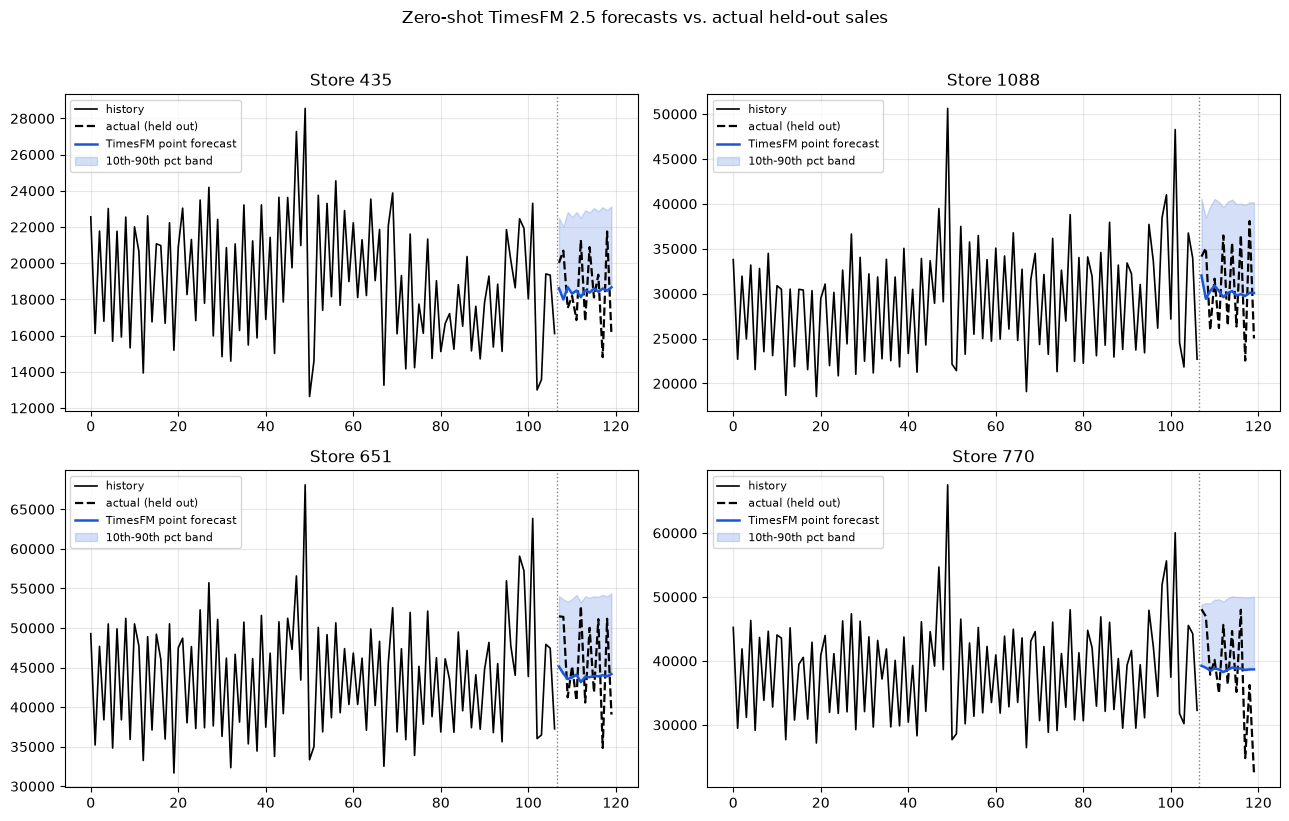

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sample_idx = np.random.default_rng(SEED).choice(len(store_ids), size=4, replace=False)
weeks = np.arange(TOTAL_LEN)

for ax, idx in zip(axes.ravel(), sample_idx):
    sid = store_ids[idx]
    full_series = sales_by_store[sid]
    ax.plot(weeks[:CONTEXT_LEN], full_series[:CONTEXT_LEN], color="black", lw=1.2, label="history")
    ax.plot(weeks[CONTEXT_LEN:], full_series[CONTEXT_LEN:], color="black", lw=1.6,
            ls="--", label="actual (held out)")
    ax.plot(weeks[CONTEXT_LEN:], point_forecast[idx], color="#1a56db", lw=1.8, label="TimesFM point forecast")
    q10 = quantile_forecast[idx, :, quantile_to_channel[0.1]]
    q90 = quantile_forecast[idx, :, quantile_to_channel[0.9]]
    ax.fill_between(weeks[CONTEXT_LEN:], q10, q90, color="#1a56db", alpha=0.18, label="10th-90th pct band")
    ax.axvline(CONTEXT_LEN - 0.5, color="grey", ls=":", lw=1)
    ax.set_title(f"Store {sid}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("Zero-shot TimesFM 2.5 forecasts vs. actual held-out sales", y=1.02)
plt.tight_layout()
plt.show()

<a id="baselines"></a>
## 11. Baselines & evaluation

We report three complementary metrics per store, then average:

- **MAE** — mean absolute error, in the original sales units.
- **sMAPE** — symmetric mean absolute percentage error, scale-free, comparable across stores of
  very different sizes.
- **MASE-style scaled MAE** — the test-horizon MAE divided by the *in-sample* mean absolute
  **52-week seasonal difference** (`|x_t - x_{t-52}|`, averaged over the context period). This is
  methodologically the same *style* of scaled-MAE metric used in TimesFM's own paper (Section 5)
  — we use it here to keep our evaluation philosophy consistent with the literature, **not** to
  claim our absolute numbers are comparable to the paper's Monash results (different dataset,
  different setup).

Baselines, run against the **same** held-out 13-week window as TimesFM:

- **Naive** — repeat the last observed week's sales for all 13 future weeks.
- **Seasonal-naive** — repeat the value from 52 weeks earlier (`x_{t-52}`), the standard
  "same week last year" baseline for weekly retail data.
- **ETS (Holt-Winters)** — a classical additive trend + 52-week-seasonal exponential smoothing
  model, fit **per store** via `statsmodels`. Fitting ETS on all 1,115 stores individually is
  slow and not the point of this tutorial, so we fit it on a **fixed random subset of 100
  stores** (seed 42) and report that subset's numbers for *all* methods side by side, so the
  comparison stays apples-to-apples. We say so explicitly rather than silently comparing
  different-sized samples.

In [8]:
def mae(actual, pred):
    return np.mean(np.abs(actual - pred), axis=-1)

def smape(actual, pred, eps=1e-8):
    return np.mean(200.0 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + eps), axis=-1)

def scaled_mae(actual, pred, history, season=52):
    naive_in_sample_mae = np.mean(np.abs(history[season:] - history[:-season]))
    return mae(actual, pred) / max(naive_in_sample_mae, eps_floor := 1e-6)

# Naive & seasonal-naive, all 1,115 stores
naive_pred = np.stack([np.full(HORIZON, c[-1]) for c in contexts])
seasonal_naive_pred = np.stack([
    sales_by_store[sid][CONTEXT_LEN - 52 : CONTEXT_LEN - 52 + HORIZON] for sid in store_ids
])

results = {}
for name, pred in [
    ("Naive (last value)", naive_pred),
    ("Seasonal-naive (t-52)", seasonal_naive_pred),
    ("TimesFM zero-shot", point_forecast),
]:
    results[name] = {
        "MAE": mae(actual_future, pred).mean(),
        "sMAPE": smape(actual_future, pred).mean(),
        "scaled_MAE": np.mean([
            scaled_mae(actual_future[i], pred[i], contexts[i]) for i in range(len(store_ids))
        ]),
    }

pd.DataFrame(results).T.round(3)

,MAE,sMAPE,scaled_MAE
Naive (last value),8700.963867,22.893,1.141
Seasonal-naive (t-52),4100.744141,10.760,0.524
TimesFM zero-shot,6081.912109,15.409,0.781


In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tqdm.auto import tqdm

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(len(store_ids), size=100, replace=False)

ets_pred = {}
ets_failures = 0
for idx in tqdm(subset_idx, desc="Fitting per-store ETS"):
    history = contexts[idx]
    try:
        fit = ExponentialSmoothing(
            history, trend="add", seasonal="add", seasonal_periods=52,
            initialization_method="estimated",
        ).fit(optimized=True)
        ets_pred[idx] = fit.forecast(HORIZON)
    except Exception:
        ets_failures += 1
        ets_pred[idx] = seasonal_naive_pred[idx]  # graceful fallback, counted below

print(f"ETS converged for {len(subset_idx) - ets_failures}/{len(subset_idx)} stores "
      f"({ets_failures} fell back to seasonal-naive)")

subset_actual = actual_future[subset_idx]
subset_results = {}
for name, pred in [
    ("Naive (last value)", naive_pred[subset_idx]),
    ("Seasonal-naive (t-52)", seasonal_naive_pred[subset_idx]),
    ("ETS (Holt-Winters, per-store)", np.stack([ets_pred[i] for i in subset_idx])),
    ("TimesFM zero-shot", point_forecast[subset_idx]),
]:
    subset_results[name] = {
        "MAE": mae(subset_actual, pred).mean(),
        "sMAPE": smape(subset_actual, pred).mean(),
    }

print(f"\nApples-to-apples comparison on the same {len(subset_idx)}-store subset:")
pd.DataFrame(subset_results).T.round(3)

Fitting per-store ETS:   0%|          | 0/100 [00:00<?, ?it/s]

ETS converged for 100/100 stores (0 fell back to seasonal-naive)

Apples-to-apples comparison on the same 100-store subset:


,MAE,sMAPE
Naive (last value),8604.400,22.675
Seasonal-naive (t-52),4162.210,10.902
"ETS (Holt-Winters, per-store)",7245.536,16.317
TimesFM zero-shot,6052.035,15.511


<a id="covariates"></a>
## 12. Covariates (XReg)

TimesFM 2.5 can incorporate **known exogenous covariates** through its XReg mechanism, via
`forecast_with_covariates()`. This method requires the model to be compiled with
`return_backcast=True` (it raises a clear `ValueError` otherwise) — it needs the model's
in-context backcast internally, to compute historical residuals for fitting the covariate
regression. That's a different compiled config than Section 10 used, so we recompile the same
model object below rather than carrying backcast output through the whole notebook.

Two modes are supported (verified directly from the installed package source):

- **`"xreg + timesfm"`** (default) — fit a linear regression of the covariates against TimesFM's
  own *residuals*, then add that correction to TimesFM's baseline forecast. Best when covariates
  explain residual variation TimesFM's pretraining couldn't have learned (e.g., *this specific
  store's* promo calendar).
- **`"timesfm + xreg"`** — fit covariates against the raw target first, then let TimesFM forecast
  the regression's residuals. Best when the covariate *is* the dominant signal.

**Which covariates are legitimate to use?** Only ones a retailer actually **knows in advance**:
`Promo`, `SchoolHoliday`, `StateHoliday`, and `Open` are all planned ahead of time (promo
calendars and holiday calendars are scheduled; store-open decisions are operational choices).
We **exclude `Customers`** (see Section 9) — it's an *outcome* correlated with `Sales`, not
something known before the fact, and including it would be evaluation leakage, not a genuine
forecasting improvement.

In [10]:
# Recompile with return_backcast=True -- same weights, just a different decode graph.
model.compile(timesfm.ForecastConfig(
    max_context=CONTEXT_LEN,
    max_horizon=128,
    normalize_inputs=True,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
    return_backcast=True,
))

dynamic_numerical = {}
for col in ["Promo", "SchoolHoliday", "StateHoliday", "Open"]:
    dynamic_numerical[col.lower()] = [
        grouped[sid][col].to_numpy(dtype=np.float32) for sid in store_ids   # full 120 weeks: known ahead
    ]

t0 = time.time()
cov_point_forecast, cov_quantile_forecast = model.forecast_with_covariates(
    inputs=contexts,
    dynamic_numerical_covariates=dynamic_numerical,
    xreg_mode="xreg + timesfm",
    normalize_xreg_target_per_input=True,
    force_on_cpu=True,   # the covariate regression is a tiny per-series ridge solve; no GPU needed
)
elapsed = time.time() - t0
cov_point_forecast = np.asarray(cov_point_forecast)
print(f"forecast_with_covariates over {len(contexts)} stores took {elapsed:.1f}s")
print(f"cov_point_forecast shape: {cov_point_forecast.shape}")

cov_mae = mae(actual_future, cov_point_forecast).mean()
cov_smape = smape(actual_future, cov_point_forecast).mean()
print(f"\nTimesFM + covariates  -> MAE: {cov_mae:.2f}  sMAPE: {cov_smape:.2f}")
print(f"TimesFM zero-shot only -> MAE: {results['TimesFM zero-shot']['MAE']:.2f}  "
      f"sMAPE: {results['TimesFM zero-shot']['sMAPE']:.2f}")

forecast_with_covariates over 1115 stores took 99.7s
cov_point_forecast shape: (1115, 13)

TimesFM + covariates  -> MAE: 3265.85  sMAPE: 8.80
TimesFM zero-shot only -> MAE: 6081.91  sMAPE: 15.41


<a id="finetuning"></a>
## 13. Fine-tuning with LoRA

Zero-shot is TimesFM's headline feature, but sometimes you have enough domain data to be worth
adapting the model. TimesFM 2.5 ships as a standard `transformers.PreTrainedModel`
(`TimesFm2_5ModelForPrediction`), which means the entire PEFT ecosystem — LoRA, QLoRA, etc. —
works out of the box, with **no custom training loop required beyond standard PyTorch**: the
model's forward pass computes a training loss natively when `future_values` are supplied.

This section follows Google's own official LoRA fine-tuning example
([`timesfm-forecasting/examples/finetuning/`](https://github.com/google-research/timesfm/tree/master/timesfm-forecasting/examples/finetuning)),
re-implemented inline here (rather than shelled out to a script) so every step is visible and
explained, run on **our own Rossmann train/test split** so results are directly comparable to
Sections 10–12:

- **No external normalization** — TimesFM applies its own internal RevIN (Section 2.3); we feed
  raw sales values, never our own z-scored/scaled versions.
- **Random window sampling** — following Chronos-2's data-efficient training recipe, each
  training example is a random `(context, horizon)` window sliced from a random store, rather
  than one fixed window per store — this multiplies the effective size of a small dataset.
- **`target_modules="all-linear"`** — LoRA adapters on every linear layer; at rank 4 this trains
  only **~0.6%** of the model's parameters (per Google's own README).
- **Leakage boundary**: every training window is sampled **only from weeks 0–106** — the same
  107-week history used for zero-shot forecasting. The final 13-week test window is never seen
  during fine-tuning, so the comparison to Sections 10–12 is fair.

We deliberately train for fewer steps than Google's own example defaults
(`--num_samples 5000 --epochs 10`) — **3,000 samples, 8 epochs** — purely to keep this tutorial's
end-to-end runtime reasonable; scale these up for a production adapter.

In [11]:
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from peft import LoraConfig, get_peft_model
from transformers import TimesFm2_5ModelForPrediction

# Free the native-package model's GPU memory before loading the transformers checkpoint.
del model
torch.cuda.empty_cache()

FT_CONTEXT_LEN = 64     # must be a multiple of 32 (the input patch size)
FT_HORIZON_LEN = HORIZON
FT_NUM_SAMPLES = 3000
FT_EPOCHS = 8
FT_BATCH_SIZE = 32
FT_LR = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Fine-tuning on: {device}")


class RandomWindowDataset(Dataset):
    """Randomly-sampled (context, horizon) windows, restricted to the pre-test-window region."""

    def __init__(self, series_list, context_len, horizon_len, num_samples, seed):
        self.series_list = series_list
        self.context_len = context_len
        self.horizon_len = horizon_len
        rng = np.random.default_rng(seed)
        min_len = context_len + horizon_len
        valid = [i for i, s in enumerate(series_list) if len(s) >= min_len]
        self.samples = [
            (idx, rng.integers(0, len(series_list[idx]) - min_len + 1))
            for idx in rng.choice(valid, size=num_samples)
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        idx, start = self.samples[i]
        s = self.series_list[idx]
        end = start + self.context_len + self.horizon_len
        context = torch.tensor(s[start:start + self.context_len], dtype=torch.float32)
        target = torch.tensor(s[start + self.context_len:end], dtype=torch.float32)
        return context, target


class LastWindowDataset(Dataset):
    """Validation set: the most recent window within the training region (not the held-out test)."""

    def __init__(self, series_list, context_len, horizon_len):
        min_len = context_len + horizon_len
        self.items = [
            (
                torch.tensor(s[-min_len:-horizon_len], dtype=torch.float32),
                torch.tensor(s[-horizon_len:], dtype=torch.float32),
            )
            for s in series_list if len(s) >= min_len
        ]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


# `contexts` holds weeks 0-106 for every store -- fine-tuning never touches weeks 107-119.
train_ds = RandomWindowDataset(contexts, FT_CONTEXT_LEN, FT_HORIZON_LEN, FT_NUM_SAMPLES, SEED)
val_ds = LastWindowDataset(contexts, FT_CONTEXT_LEN, FT_HORIZON_LEN)
train_loader = DataLoader(train_ds, batch_size=FT_BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=FT_BATCH_SIZE)
print(f"Train windows: {len(train_ds)} ({len(train_loader)} batches) | Val windows: {len(val_ds)}")

Fine-tuning on: cuda
Train windows: 3000 (93 batches) | Val windows: 1115


In [12]:
# Load the Transformers port for fine-tuning. We avoid `device_map` here to keep the
# dependency footprint small (no Accelerate required); we explicitly move the model to the chosen
# device instead.

dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
ft_model = TimesFm2_5ModelForPrediction.from_pretrained(
    "google/timesfm-2.5-200m-transformers",
    torch_dtype=dtype,
)
ft_model.to(device)
print(f"Base model context length: {ft_model.config.context_length}")

lora_config = LoraConfig(
    r=4, lora_alpha=8, target_modules="all-linear", lora_dropout=0.05, bias="none",
)
ft_model = get_peft_model(ft_model, lora_config)
ft_model.print_trainable_parameters()

optimizer = torch.optim.AdamW(ft_model.parameters(), lr=FT_LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FT_EPOCHS * len(train_loader)
)


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Base model context length: 16384
trainable params: 1,382,912 || all params: 232,672,192 || trainable%: 0.5944


In [13]:
history_log = []
for epoch in range(1, FT_EPOCHS + 1):
    ft_model.train()
    train_loss, n_batches = 0.0, 0
    for context, target in train_loader:
        context, target = context.to(device), target.to(device)
        out = ft_model(past_values=context, future_values=target, forecast_context_len=FT_CONTEXT_LEN)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()
        train_loss += out.loss.item()
        n_batches += 1
    train_loss /= max(n_batches, 1)

    ft_model.eval()
    val_loss, n_val = 0.0, 0
    with torch.no_grad():
        for context, target in val_loader:
            context, target = context.to(device), target.to(device)
            out = ft_model(past_values=context, future_values=target, forecast_context_len=FT_CONTEXT_LEN)
            val_loss += out.loss.item()
            n_val += 1
    val_loss /= max(n_val, 1)

    history_log.append((epoch, train_loss, val_loss))
    print(f"epoch {epoch}/{FT_EPOCHS} - train loss {train_loss:.4f} - val loss {val_loss:.4f}")

epoch 1/8 - train loss 2.5041 - val loss 1.6288


epoch 2/8 - train loss 1.9958 - val loss 1.1930


epoch 3/8 - train loss 1.6949 - val loss 1.0231


epoch 4/8 - train loss 1.4196 - val loss 0.9320


epoch 5/8 - train loss 1.2121 - val loss 0.8734


epoch 6/8 - train loss 1.0661 - val loss 0.8474


epoch 7/8 - train loss 0.9772 - val loss 0.8332


epoch 8/8 - train loss 0.9728 - val loss 0.8306


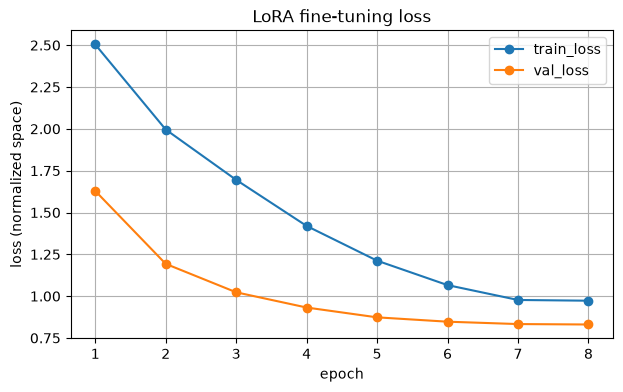

In [14]:
hist_df = pd.DataFrame(history_log, columns=["epoch", "train_loss", "val_loss"])
hist_df.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", figsize=(7, 4), grid=True)
plt.title("LoRA fine-tuning loss")
plt.ylabel("loss (normalized space)")
plt.show()

### Evaluating the fine-tuned model on the true held-out test window

Now we forecast the **same** final 13 weeks used in Sections 10–12, using the fine-tuned
adapter, with `future_values=None` (pure inference) — the forward pass returns
`mean_predictions` directly.

In [15]:
ft_model.eval()
ft_preds = np.zeros((len(store_ids), HORIZON), dtype=np.float32)
eval_context_len = FT_CONTEXT_LEN  # same context length the adapter was trained on

with torch.no_grad():
    for start in range(0, len(store_ids), FT_BATCH_SIZE):
        batch_idx = range(start, min(start + FT_BATCH_SIZE, len(store_ids)))
        batch_context = torch.tensor(
            np.stack([contexts[i][-eval_context_len:] for i in batch_idx]), dtype=torch.float32
        ).to(device)
        out = ft_model(past_values=batch_context, forecast_context_len=eval_context_len)
        ft_preds[list(batch_idx)] = out.mean_predictions[:, :HORIZON].float().cpu().numpy()

ft_mae = mae(actual_future, ft_preds).mean()
ft_smape = smape(actual_future, ft_preds).mean()
print(f"TimesFM + LoRA fine-tuning -> MAE: {ft_mae:.2f}  sMAPE: {ft_smape:.2f}")

TimesFM + LoRA fine-tuning -> MAE: 4720.39  sMAPE: 11.90


<a id="final"></a>
## 14. Final comparison

Every method below is evaluated on the identical 1,115-store, 13-week held-out window (the ETS
row is the 100-store subset from Section 11 — noted, not hidden).

In [16]:
final_table = pd.DataFrame({
    "Naive (last value)": results["Naive (last value)"],
    "Seasonal-naive (t-52)": results["Seasonal-naive (t-52)"],
    "TimesFM zero-shot": results["TimesFM zero-shot"],
    "TimesFM + covariates (XReg)": {"MAE": cov_mae, "sMAPE": cov_smape, "scaled_MAE": np.nan},
    "TimesFM + LoRA fine-tuning": {"MAE": ft_mae, "sMAPE": ft_smape, "scaled_MAE": np.nan},
}).T.round(3)

print("Full 1,115-store comparison (ETS omitted here -- see Section 11 for the 100-store subset):")
final_table

Full 1,115-store comparison (ETS omitted here -- see Section 11 for the 100-store subset):


,MAE,sMAPE,scaled_MAE
Naive (last value),8700.964,22.893,1.141
Seasonal-naive (t-52),4100.744,10.760,0.524
TimesFM zero-shot,6081.913,15.409,0.781
TimesFM + covariates (XReg),3265.854,8.798,NaN
TimesFM + LoRA fine-tuning,4720.392,11.900,NaN


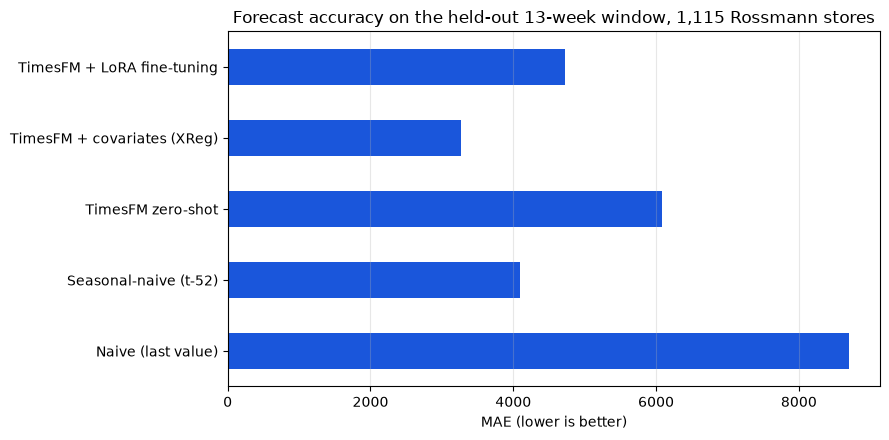

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
final_table["MAE"].plot(kind="barh", ax=ax, color="#1a56db")
ax.set_xlabel("MAE (lower is better)")
ax.set_title("Forecast accuracy on the held-out 13-week window, 1,115 Rossmann stores")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

**Read these numbers honestly, not triumphantly.** Whichever method comes out on top in your
run is the real result — report it as such. A few things worth checking with your own eyes
before drawing conclusions from any single run like this one:

- Zero-shot TimesFM is being compared against a seasonal-naive baseline that gets to "cheat" by
  using the real value from exactly 52 weeks prior — a strong baseline for clean weekly retail
  seasonality. If TimesFM doesn't clearly beat it here, that is itself an informative, legitimate
  result about this particular dataset, not a failure of the tutorial.
- The LoRA fine-tuning run here uses deliberately reduced steps/samples versus Google's own
  example defaults (Section 13) to keep runtime reasonable — a production adapter trained longer
  may look different.
- Covariates help most when the excluded-vs-included variables genuinely explain residual
  variance; on a dataset where promotions/holidays are already implicitly captured by
  TimesFM's pretraining priors on retail-like seasonality, the XReg lift may be modest.

<a id="references"></a>
## 15. References

- Das, A. et al. *A decoder-only foundation model for time-series forecasting*, ICML 2024.
  [arXiv:2310.10688](https://arxiv.org/abs/2310.10688)
- Official repository: [github.com/google-research/timesfm](https://github.com/google-research/timesfm)
- Official LoRA fine-tuning example: [timesfm-forecasting/examples/finetuning](https://github.com/google-research/timesfm/tree/master/timesfm-forecasting/examples/finetuning)
- Official covariates (XReg) example: [timesfm-forecasting/examples/covariates-forecasting](https://github.com/google-research/timesfm/tree/master/timesfm-forecasting/examples/covariates-forecasting)
- Hugging Face model collection: [huggingface.co/collections/google/timesfm-release](https://huggingface.co/collections/google/timesfm-release-66e4be5fdb56e960c1e482a6)
- PyPI package: [pypi.org/project/timesfm](https://pypi.org/project/timesfm/)
- Google Research blog: [research.google/blog/a-decoder-only-foundation-model-for-time-series-forecasting](https://research.google/blog/a-decoder-only-foundation-model-for-time-series-forecasting/)
- BigQuery ML TimesFM docs: [cloud.google.com/bigquery/docs/timesfm-model](https://cloud.google.com/bigquery/docs/timesfm-model)
- Vertex AI operationalization guide: [googlecloudplatform.github.io/.../operationalizing_timesfm_on_vertexai](https://googlecloudplatform.github.io/applied-ai-engineering-samples/research-operationalization/timesfm/operationalizing_timesfm_on_vertexai/)
- GIFT-Eval leaderboard (check live for current cross-model rankings): [huggingface.co/spaces/Salesforce/GIFT-Eval](https://huggingface.co/spaces/Salesforce/GIFT-Eval)
- Dataset: retail sales parquet mirrored on AutoGluon's public S3 bucket, as used by the official
  TimesFM LoRA fine-tuning example and the Chronos-2 quickstart notebook.

## What you now know

You can now: explain TimesFM's patched-decoder architecture and how it differs across 1.0/2.0/2.5;
load a pretrained checkpoint and get zero-shot point + quantile forecasts; add legitimate,
leakage-safe exogenous covariates via XReg; fine-tune TimesFM with LoRA on your own data without
writing a custom training loop; and benchmark all of it honestly against classical baselines.

**Natural next steps:** try a longer-context dataset to exercise 2.5's 16k-token context ceiling;
run the [GIFT-Eval](https://huggingface.co/spaces/Salesforce/GIFT-Eval) harness against your own
domain; try the full 1,913-day daily M5 competition data instead of this weekly aggregate; or
deploy the zero-shot path directly in BigQuery ML (`AI.FORECAST`) instead of a self-hosted
notebook.